# Step 10 — Related-Work Evidence and Comparability

## tl;dr

This artifact-only notebook turns a verified primary-literature snapshot into a traceable related-work evidence matrix, an explicit comparability audit, a venue-neutral Related Work section, and an expanded manuscript copy.

The external studies do **not** share this project's exact split, metric population, inference protocol, or post-processing contract. Therefore, this notebook prohibits leaderboard ordering and state-of-the-art/superiority claims. It positions the study by method lineage, evaluation governance, and documented limitations.

### Immutable boundary

- Read only the sealed Step 09 manuscript, gate, and signature.
- Do not open dataset sources, test images, masks, probabilities, models, loaders, or checkpoints.
- Do not rerun inference or derive any new test statistic.
- Use the embedded source snapshot for reproducible offline execution.
- Write every generated artifact only to this phase's `outputs/` directory.


## Context & Methods

### Key Assumptions

- Primary articles and official publisher/author pages are preferred over reviews and aggregators.
- A reported Dice value is descriptive of its own study only unless dataset, split, metric aggregation, inclusion rules, and post-processing are all aligned.
- This project's held-out results remain the sealed Step 04/05 values already reconciled in Step 09.
- The literature snapshot is current as of 5 August 2026 and must be refreshed before a future submission if material time has passed.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

STEP_DIR = Path.cwd().resolve()
if STEP_DIR.name != "step_10_related_work_evidence_and_comparability":
    candidate = STEP_DIR / "step_10_related_work_evidence_and_comparability"
    if candidate.is_dir():
        STEP_DIR = candidate.resolve()
PART2 = STEP_DIR.parent
S9 = PART2 / "step_09_internal_peer_review_and_claim_consistency" / "outputs"
OUT = STEP_DIR / "outputs"
OUT.mkdir(parents=True, exist_ok=True)

MANIFEST_SHA256 = "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
TEST_RUN_ID = "871d289b-bf6b-4346-978f-2df02ade26ab"
SNAPSHOT_DATE = "2026-08-05"
CREATED_UTC = datetime.now(timezone.utc).isoformat()

def sha256(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

def save_json(obj, name):
    path = OUT / name
    path.write_text(json.dumps(obj, indent=2, sort_keys=True), encoding="utf-8")
    return path

def save_csv(df, name):
    path = OUT / name
    df.to_csv(path, index=False)
    return path

print("Artifact-only literature phase; no dataset or test-source path is defined.")

Artifact-only literature phase; no dataset or test-source path is defined.


## Data

### 1. Verify the sealed Step 09 boundary


In [2]:
gate9 = load_json(S9 / "gate_result.json")
sig9 = load_json(S9 / "step_09_signature.json")
manuscript_path = S9 / "PAPER_DRAFT_SCIENTIFICALLY_REVISED.md"
manuscript = manuscript_path.read_text(encoding="utf-8")

signed_rows = []
for rel, expected in sig9["signed_artifacts"].items():
    path = PART2 / rel
    actual = sha256(path) if path.is_file() else None
    signed_rows.append({"artifact": rel, "expected_sha256": expected, "actual_sha256": actual,
                        "passed": actual == expected})
signed = pd.DataFrame(signed_rows)

checks = [
    ("step09_result_level", gate9.get("result_level") == "INTERNAL_PEER_REVIEW_COMPLETE", gate9.get("result_level")),
    ("step09_scientific_consistency", gate9.get("scientific_consistency_passed") is True, gate9.get("scientific_consistency_passed")),
    ("submission_remains_closed", gate9.get("submission_ready") is False, gate9.get("submission_ready")),
    ("formal_model_acceptance_failed", gate9.get("formal_model_acceptance_passed") is False, gate9.get("formal_model_acceptance_passed")),
    ("manifest_hash", gate9.get("manifest_sha256") == MANIFEST_SHA256, gate9.get("manifest_sha256")),
    ("test_run_id", gate9.get("source_test_run_id") == TEST_RUN_ID, gate9.get("source_test_run_id")),
    ("test_images_not_accessed", gate9.get("test_images_accessed") is False, gate9.get("test_images_accessed")),
    ("test_inference_not_rerun", gate9.get("test_inference_rerun") is False, gate9.get("test_inference_rerun")),
    ("revised_manuscript_exists", manuscript_path.is_file(), str(manuscript_path)),
    ("step09_signature_valid", bool(len(signed)) and bool(signed.passed.all()), f"{int(signed.passed.sum())}/{len(signed)}"),
]
verification = pd.DataFrame(checks, columns=["check", "passed", "observed"])
save_csv(verification, "input_verification.csv")
assert verification.passed.all(), verification.loc[~verification.passed].to_dict("records")
assert signed.passed.all(), signed.loc[~signed.passed].to_dict("records")
print(f"PASS: {verification.passed.sum()}/{len(verification)} sealed-boundary checks")

PASS: 10/10 sealed-boundary checks


### 2. Build the primary-literature evidence snapshot

The records below contain bibliographic facts and deliberately bounded evidence statements captured from primary articles or official publisher/author pages. Numeric results are retained only with their reported aggregation context.


In [3]:
records = [
 {"citation_key":"Bilic2023LiTS","year":2023,"title":"The Liver Tumor Segmentation Benchmark (LiTS)","venue":"Medical Image Analysis","doi":"10.1016/j.media.2022.102680","url":"https://www.sciencedirect.com/science/article/pii/S1361841522003085","source_kind":"primary benchmark report","direct_lits":True,"theme":"benchmark and evaluation","method_family":"multi-method benchmark","dimensionality":"mixed","dataset_scope":"LiTS benchmark","evaluation_scope":"challenge benchmark","reported_metric_text":"No single comparator value extracted for ranking","metric_population":"multiple challenge metrics and submissions","postprocessing":"varies by submission","evidence_use":"Dataset benchmark context and evaluation heterogeneity","claim_boundary":"Do not treat benchmark ranks as directly comparable to this custom split."},
 {"citation_key":"Christ2017CFCN","year":2017,"title":"Automatic Liver and Tumor Segmentation of CT and MRI Volumes Using Cascaded Fully Convolutional Neural Networks","venue":"arXiv / MICCAI-era work","doi":"10.48550/arXiv.1702.05970","url":"https://arxiv.org/abs/1702.05970","source_kind":"primary article","direct_lits":True,"theme":"cascaded ROI segmentation","method_family":"cascaded FCN","dimensionality":"2D with volumetric pipeline","dataset_scope":"liver CT/MRI including LiTS-era data","evaluation_scope":"study-specific","reported_metric_text":"Not extracted for cross-study ranking","metric_population":"study-specific","postprocessing":"pipeline-specific","evidence_use":"Lineage for liver-first then tumour segmentation","claim_boundary":"Architecture lineage only; protocol is not identical."},
 {"citation_key":"Chlebus2018ObjectPost","year":2018,"title":"Automatic liver tumor segmentation in CT with fully convolutional neural networks and object-based postprocessing","venue":"Scientific Reports","doi":"10.1038/s41598-018-33860-7","url":"https://pmc.ncbi.nlm.nih.gov/articles/PMC6195599/","source_kind":"primary article","direct_lits":True,"theme":"false-positive control","method_family":"FCN plus object post-processing","dimensionality":"2D/3D object pipeline","dataset_scope":"LiTS challenge test set","evaluation_scope":"70 challenge test cases","reported_metric_text":"Mean Dice 0.65 on challenge test; object post-processing reduced false positives by 85%","metric_population":"challenge-defined / object-aware reporting","postprocessing":"random-forest object filtering","evidence_use":"Shows sensitivity to explicit false-positive post-processing","claim_boundary":"Not comparable to this no-post-processing frozen policy."},
 {"citation_key":"Li2018HDenseUNet","year":2018,"title":"H-DenseUNet: Hybrid Densely Connected UNet for Liver and Tumor Segmentation From CT Volumes","venue":"IEEE Transactions on Medical Imaging","doi":"10.1109/TMI.2018.2845918","url":"https://pubmed.ncbi.nlm.nih.gov/29994201/","source_kind":"primary article","direct_lits":True,"theme":"2D/3D context fusion","method_family":"hybrid dense U-Net","dimensionality":"hybrid 2D/3D","dataset_scope":"LiTS","evaluation_scope":"challenge-style evaluation","reported_metric_text":"Tumour Dice values are study/challenge-protocol specific; excluded from ranking here","metric_population":"per-case/global definitions differ from current primary endpoint","postprocessing":"study-specific","evidence_use":"Representative hybrid volumetric-context method","claim_boundary":"Do not compare reported challenge Dice directly to mean positive-patient Dice."},
 {"citation_key":"Jin2020RAUNet","year":2020,"title":"RA-UNet: A Hybrid Deep Attention-Aware Network to Extract Liver and Tumor in CT Scans","venue":"Frontiers in Bioengineering and Biotechnology","doi":"10.3389/fbioe.2020.605132","url":"https://pmc.ncbi.nlm.nih.gov/articles/PMC7785874/","source_kind":"primary article","direct_lits":True,"theme":"attention and 3D context","method_family":"residual attention U-Net","dimensionality":"3D","dataset_scope":"LiTS and 3DIRCADb","evaluation_scope":"official LiTS-style and external dataset experiments","reported_metric_text":"LiTS tumour Dice per case 0.595; Dice global 0.795","metric_population":"paper-defined per-case and global Dice","postprocessing":"paper-specific pipeline","evidence_use":"Representative attention-aware volumetric model with both per-case and global reporting","claim_boundary":"Values illustrate aggregation dependence; they are not a head-to-head comparison."},
 {"citation_key":"Isensee2021nnUNet","year":2021,"title":"nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation","venue":"Nature Methods","doi":"10.1038/s41592-020-01008-z","url":"https://www.nature.com/articles/s41592-020-01008-z","source_kind":"primary article","direct_lits":False,"theme":"self-configuring baseline","method_family":"self-configuring U-Net framework","dimensionality":"2D and 3D ensembles","dataset_scope":"23 biomedical segmentation datasets","evaluation_scope":"cross-task benchmarking","reported_metric_text":"No LiTS-specific value extracted for ranking","metric_population":"dataset-specific benchmark metrics","postprocessing":"automatically configured where applicable","evidence_use":"Strong reproducible baseline framework for future governed comparisons","claim_boundary":"Not evaluated under this project's corrected split and frozen policy."},
 {"citation_key":"Ronneberger2015UNet","year":2015,"title":"U-Net: Convolutional Networks for Biomedical Image Segmentation","venue":"MICCAI","doi":"10.1007/978-3-319-24574-4_28","url":"https://arxiv.org/abs/1505.04597","source_kind":"primary article","direct_lits":False,"theme":"architecture lineage","method_family":"U-Net","dimensionality":"2D","dataset_scope":"microscopy","evaluation_scope":"task-specific","reported_metric_text":"Not a LiTS comparator","metric_population":"task-specific","postprocessing":"task-specific","evidence_use":"Decoder/skip-connection architecture lineage","claim_boundary":"Foundational architecture citation only."},
 {"citation_key":"Cicek2016ThreeDUNet","year":2016,"title":"3D U-Net: Learning Dense Volumetric Segmentation from Sparse Annotation","venue":"MICCAI","doi":"10.1007/978-3-319-46723-8_49","url":"https://arxiv.org/abs/1606.06650","source_kind":"primary article","direct_lits":False,"theme":"volumetric context","method_family":"3D U-Net","dimensionality":"3D","dataset_scope":"Xenopus kidney microscopy","evaluation_scope":"task-specific","reported_metric_text":"Not a LiTS comparator","metric_population":"task-specific","postprocessing":"task-specific","evidence_use":"Volumetric segmentation lineage","claim_boundary":"Motivates 3D context; not evidence of LiTS performance."},
 {"citation_key":"Sudre2017GeneralizedDice","year":2017,"title":"Generalised Dice overlap as a deep learning loss function for highly unbalanced segmentations","venue":"DLMIA / MICCAI workshop","doi":"10.1007/978-3-319-67558-9_28","url":"https://arxiv.org/abs/1707.03237","source_kind":"primary article","direct_lits":False,"theme":"class imbalance","method_family":"loss function","dimensionality":"general","dataset_scope":"imbalanced segmentation tasks","evaluation_scope":"method study","reported_metric_text":"Not a LiTS comparator","metric_population":"task-specific","postprocessing":"not central","evidence_use":"Loss-design context for severe foreground imbalance","claim_boundary":"Does not validate the current recall-loss checkpoint independently."},
 {"citation_key":"Oktay2018AttentionUNet","year":2018,"title":"Attention U-Net: Learning Where to Look for the Pancreas","venue":"arXiv","doi":"10.48550/arXiv.1804.03999","url":"https://arxiv.org/abs/1804.03999","source_kind":"primary article","direct_lits":False,"theme":"attention mechanisms","method_family":"attention U-Net","dimensionality":"2D/3D formulation","dataset_scope":"pancreas CT","evaluation_scope":"task-specific","reported_metric_text":"Not a LiTS comparator","metric_population":"task-specific","postprocessing":"study-specific","evidence_use":"Attention-gate lineage for organ/lesion localization","claim_boundary":"Different anatomy, cohort, and protocol."},
 {"citation_key":"MaierHein2018Rankings","year":2018,"title":"Why rankings of biomedical image analysis competitions should be interpreted with care","venue":"Nature Communications","doi":"10.1038/s41467-018-07619-7","url":"https://www.nature.com/articles/s41467-018-07619-7","source_kind":"primary methodological study","direct_lits":False,"theme":"evaluation validity","method_family":"challenge meta-research","dimensionality":"not applicable","dataset_scope":"biomedical image-analysis challenges","evaluation_scope":"ranking stability analysis","reported_metric_text":"Rankings can vary with test cases, metrics, aggregation, and observers","metric_population":"multi-challenge methodological analysis","postprocessing":"not applicable","evidence_use":"Justifies explicit no-leaderboard comparability rule","claim_boundary":"Supports caution, not a performance comparison."},
 {"citation_key":"Sandler2018MobileNetV2","year":2018,"title":"MobileNetV2: Inverted Residuals and Linear Bottlenecks","venue":"CVPR","doi":"10.1109/CVPR.2018.00474","url":"https://openaccess.thecvf.com/content_cvpr_2018/html/Sandler_MobileNetV2_Inverted_Residuals_CVPR_2018_paper","source_kind":"primary article","direct_lits":False,"theme":"efficient encoder","method_family":"MobileNetV2","dimensionality":"2D","dataset_scope":"natural-image classification/detection","evaluation_scope":"task-specific","reported_metric_text":"Not a LiTS comparator","metric_population":"computer-vision task metrics","postprocessing":"not applicable","evidence_use":"Encoder architecture provenance","claim_boundary":"Architecture citation only; no medical-performance implication."},
 {"citation_key":"Tejani2024CLAIM","year":2024,"title":"Checklist for Artificial Intelligence in Medical Imaging (CLAIM): 2024 Update","venue":"Radiology: Artificial Intelligence","doi":"10.1148/ryai.240300","url":"https://pubs.rsna.org/doi/10.1148/ryai.240300","source_kind":"primary reporting guideline","direct_lits":False,"theme":"reporting governance","method_family":"reporting checklist","dimensionality":"not applicable","dataset_scope":"medical imaging AI","evaluation_scope":"reporting framework","reported_metric_text":"No performance comparator","metric_population":"not applicable","postprocessing":"not applicable","evidence_use":"Reporting completeness and transparent governance","claim_boundary":"Reporting guidance is not evidence of clinical validity."},
]
lit = pd.DataFrame(records)
lit["primary_source_verified"] = True
lit["snapshot_date"] = SNAPSHOT_DATE
save_csv(lit, "primary_literature_evidence.csv")

assert lit.citation_key.is_unique
assert len(lit) >= 12
assert int(lit.direct_lits.sum()) >= 5
assert lit.primary_source_verified.all()
assert lit.url.str.startswith("https://").all()

source_snapshot = {
    "snapshot_date": SNAPSHOT_DATE,
    "source_count": len(lit),
    "direct_lits_source_count": int(lit.direct_lits.sum()),
    "source_policy": "Primary article or official publisher/author page; no secondary numeric claim used for ranking.",
    "refresh_required_before_submission": True,
    "records": lit[["citation_key", "doi", "url", "source_kind"]].to_dict("records"),
}
save_json(source_snapshot, "source_snapshot.json")
print(f"PASS: {len(lit)} primary sources; {int(lit.direct_lits.sum())} directly concern LiTS")

PASS: 13 primary sources; 5 directly concern LiTS


## Results

### 3. Audit cross-study comparability and map evidence themes


In [4]:
current = {
 "citation_key":"CurrentStudy","year":2026,"title":"Current frozen two-checkpoint maximum-fusion study",
 "direct_lits":True,"theme":"frozen fusion and failure reporting","method_family":"two MobileNetV2 U-Nets; pixelwise maximum fusion",
 "dimensionality":"2D within predicted-liver ROI","dataset_scope":"corrected LiTS build; custom patient-disjoint split",
 "evaluation_scope":"one-time held-out 14-volume test; 13 tumour-positive patients",
 "reported_metric_text":"Mean positive-patient Dice 0.5073 (95% bootstrap interval 0.3442–0.6594); global Dice 0.7677",
 "metric_population":"mean over tumour-positive patients plus global pixel aggregation","postprocessing":"none",
 "evidence_use":"Current study","claim_boundary":"Formal model acceptance failed because V121 missed the minimum-patient floor."}

comparison = pd.concat([pd.DataFrame([current]), lit[[
    "citation_key","year","title","direct_lits","theme","method_family","dimensionality","dataset_scope",
    "evaluation_scope","reported_metric_text","metric_population","postprocessing","evidence_use","claim_boundary"
]]], ignore_index=True)
comparison.insert(0, "study_role", ["current study"] + ["external primary source"] * len(lit))
save_csv(comparison, "literature_comparison_matrix.csv")

audit_rows = []
for row in lit.itertuples(index=False):
    same_dataset_family = bool(row.direct_lits)
    exact_split_aligned = False
    metric_population_aligned = False
    postprocessing_aligned = str(row.postprocessing).strip().lower() == "none"
    inclusion_rules_aligned = False
    score = sum([same_dataset_family, exact_split_aligned, metric_population_aligned,
                 postprocessing_aligned, inclusion_rules_aligned])
    audit_rows.append({
        "citation_key": row.citation_key,
        "same_dataset_family": same_dataset_family,
        "exact_split_aligned": exact_split_aligned,
        "metric_population_aligned": metric_population_aligned,
        "postprocessing_aligned": postprocessing_aligned,
        "inclusion_rules_aligned": inclusion_rules_aligned,
        "comparability_score_0_to_5": score,
        "comparability_level": "limited" if score >= 1 else "context only",
        "quantitative_ranking_allowed": False,
        "reason": "No external paper matches the corrected split, endpoint population, frozen ROI/fusion policy, and inclusion rules.",
    })
audit = pd.DataFrame(audit_rows)
save_csv(audit, "comparability_audit.csv")
assert not audit.quantitative_ranking_allowed.any()

themes = ["benchmark and evaluation","cascaded ROI segmentation","false-positive control","2D/3D context fusion",
          "attention and 3D context","self-configuring baseline","architecture lineage","volumetric context",
          "class imbalance","attention mechanisms","evaluation validity","efficient encoder","reporting governance"]
theme_rows = []
for theme in themes:
    keys = lit.loc[lit.theme.eq(theme), "citation_key"].tolist()
    theme_rows.append({"theme": theme, "source_count": len(keys), "citation_keys": ";".join(keys),
                       "covered": len(keys) > 0})
theme_matrix = pd.DataFrame(theme_rows)
save_csv(theme_matrix, "related_work_theme_matrix.csv")
assert theme_matrix.covered.all()

insertion = pd.DataFrame([
 ("Introduction / Related work","cascaded liver-first ROI lineage","Christ2017CFCN;Chlebus2018ObjectPost"),
 ("Introduction / Related work","hybrid volumetric context and attention","Li2018HDenseUNet;Jin2020RAUNet;Cicek2016ThreeDUNet;Oktay2018AttentionUNet"),
 ("Introduction / Related work","reproducible baseline context","Isensee2021nnUNet"),
 ("Introduction / Related work","imbalance-aware optimization","Sudre2017GeneralizedDice"),
 ("Introduction / Related work","evaluation and ranking caution","Bilic2023LiTS;MaierHein2018Rankings"),
 ("Methods","encoder provenance","Ronneberger2015UNet;Sandler2018MobileNetV2"),
 ("Governance","reporting framework","Tejani2024CLAIM"),
], columns=["manuscript_location","evidence_purpose","citation_keys"])
save_csv(insertion, "citation_insertion_plan.csv")
print("PASS: comparability is explicitly limited; quantitative ranking is disabled for every external source")

PASS: comparability is explicitly limited; quantitative ranking is disabled for every external source


### 4. Produce the expanded Related Work text and manuscript copy


In [5]:
related = """## 1.1 Related work

Liver-tumour segmentation systems commonly separate organ localization from lesion delineation. Cascaded fully convolutional pipelines established a liver-first strategy [Christ2017CFCN], while later object-level filtering showed that explicit false-positive control can materially change tumour results [Chlebus2018ObjectPost]. The present study also uses a predicted-liver region, but its final tumour policy is deliberately different: two frozen two-dimensional models are fused by pixelwise maximum at a single threshold, with no post-processing.

Volumetric context has been pursued through hybrid 2D/3D dense connectivity [Li2018HDenseUNet], three-dimensional residual attention [Jin2020RAUNet], and the broader 3D U-Net lineage [Cicek2016ThreeDUNet]. Attention gates [Oktay2018AttentionUNet] and imbalance-aware overlap losses [Sudre2017GeneralizedDice] address related localization and foreground-imbalance problems. Self-configuring frameworks such as nnU-Net provide a strong reference design for future governed baseline comparisons [Isensee2021nnUNet]. These studies motivate alternatives but were not run on this project's corrected patient split under its frozen inference contract.

Cross-paper Dice values are not treated as a leaderboard here. LiTS studies differ in split, challenge submission protocol, per-case versus global aggregation, lesion inclusion, and post-processing [Bilic2023LiTS]. Competition rankings can also change with test cases, metrics, aggregation choices, and annotation conditions [MaierHein2018Rankings]. Accordingly, the numerical values in the evidence matrix retain their original populations and support context only. This study's contribution is therefore framed as a reproducible frozen-fusion evaluation with patient- and lesion-level failure reporting, not as state-of-the-art performance or clinical validation.
"""
(OUT / "RELATED_WORK_DRAFT.md").write_text(related, encoding="utf-8")

if "## 1.1 Related work" in manuscript:
    expanded = manuscript
else:
    marker = "## 2. Materials and methods"
    assert marker in manuscript, "Could not locate the Methods section insertion boundary"
    expanded = manuscript.replace(marker, related + "\n\n" + marker, 1)

for key in ["Christ2017CFCN","Chlebus2018ObjectPost","Li2018HDenseUNet","Jin2020RAUNet",
            "Cicek2016ThreeDUNet","Oktay2018AttentionUNet","Sudre2017GeneralizedDice",
            "Isensee2021nnUNet","Bilic2023LiTS","MaierHein2018Rankings"]:
    assert f"[{key}]" in expanded

refs = """@article{Bilic2023LiTS, title={The Liver Tumor Segmentation Benchmark (LiTS)}, author={Bilic, P. and Christ, P. F. and Li, H. B. and others}, journal={Medical Image Analysis}, volume={84}, pages={102680}, year={2023}, doi={10.1016/j.media.2022.102680}}
@article{Christ2017CFCN, title={Automatic Liver and Tumor Segmentation of CT and MRI Volumes Using Cascaded Fully Convolutional Neural Networks}, author={Christ, P. F. and Elshaer, M. E. A. and Ettlinger, F. and others}, journal={arXiv preprint arXiv:1702.05970}, year={2017}, doi={10.48550/arXiv.1702.05970}}
@article{Chlebus2018ObjectPost, title={Automatic liver tumor segmentation in CT with fully convolutional neural networks and object-based postprocessing}, author={Chlebus, G. and Schenk, A. and Moltz, J. H. and others}, journal={Scientific Reports}, volume={8}, year={2018}, doi={10.1038/s41598-018-33860-7}}
@article{Li2018HDenseUNet, title={H-DenseUNet: Hybrid Densely Connected UNet for Liver and Tumor Segmentation From CT Volumes}, author={Li, X. and Chen, H. and Qi, X. and others}, journal={IEEE Transactions on Medical Imaging}, volume={37}, number={12}, pages={2663--2674}, year={2018}, doi={10.1109/TMI.2018.2845918}}
@article{Jin2020RAUNet, title={RA-UNet: A Hybrid Deep Attention-Aware Network to Extract Liver and Tumor in CT Scans}, author={Jin, Q. and Meng, Z. and Sun, C. and others}, journal={Frontiers in Bioengineering and Biotechnology}, volume={8}, pages={605132}, year={2020}, doi={10.3389/fbioe.2020.605132}}
@article{Isensee2021nnUNet, title={nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation}, author={Isensee, F. and Jaeger, P. F. and Kohl, S. A. A. and others}, journal={Nature Methods}, volume={18}, pages={203--211}, year={2021}, doi={10.1038/s41592-020-01008-z}}
@inproceedings{Ronneberger2015UNet, title={U-Net: Convolutional Networks for Biomedical Image Segmentation}, author={Ronneberger, O. and Fischer, P. and Brox, T.}, booktitle={MICCAI}, year={2015}, doi={10.1007/978-3-319-24574-4_28}}
@inproceedings{Cicek2016ThreeDUNet, title={3D U-Net: Learning Dense Volumetric Segmentation from Sparse Annotation}, author={Cicek, O. and Abdulkadir, A. and Lienkamp, S. S. and others}, booktitle={MICCAI}, year={2016}, doi={10.1007/978-3-319-46723-8_49}}
@inproceedings{Sudre2017GeneralizedDice, title={Generalised Dice overlap as a deep learning loss function for highly unbalanced segmentations}, author={Sudre, C. H. and Li, W. and Vercauteren, T. and others}, booktitle={DLMIA}, year={2017}, doi={10.1007/978-3-319-67558-9_28}}
@article{Oktay2018AttentionUNet, title={Attention U-Net: Learning Where to Look for the Pancreas}, author={Oktay, O. and Schlemper, J. and Folgoc, L. L. and others}, journal={arXiv preprint arXiv:1804.03999}, year={2018}, doi={10.48550/arXiv.1804.03999}}
@article{MaierHein2018Rankings, title={Why rankings of biomedical image analysis competitions should be interpreted with care}, author={Maier-Hein, L. and Reinke, A. and Kozubek, M. and others}, journal={Nature Communications}, volume={9}, pages={5217}, year={2018}, doi={10.1038/s41467-018-07619-7}}
@inproceedings{Sandler2018MobileNetV2, title={MobileNetV2: Inverted Residuals and Linear Bottlenecks}, author={Sandler, M. and Howard, A. and Zhu, M. and others}, booktitle={CVPR}, year={2018}, doi={10.1109/CVPR.2018.00474}}
@article{Tejani2024CLAIM, title={Checklist for Artificial Intelligence in Medical Imaging (CLAIM): 2024 Update}, author={Tejani, A. S. and Klontzas, M. E. and Gatti, A. A. and others}, journal={Radiology: Artificial Intelligence}, volume={6}, number={4}, pages={e240300}, year={2024}, doi={10.1148/ryai.240300}}
"""
(OUT / "expanded_references.bib").write_text(refs, encoding="utf-8")

candidate_header = "## Candidate references (verify venue style before submission)"
if candidate_header in expanded:
    before = expanded.split(candidate_header, 1)[0].rstrip()
    after = expanded.split(candidate_header, 1)[1]
    suffix_marker = "## Submission declarations"
    suffix = suffix_marker + after.split(suffix_marker, 1)[1] if suffix_marker in after else ""
    human_refs = "\n".join([f"- [{r.citation_key}] {r.title}. {r.venue}, {r.year}. doi:{r.doi}" for r in lit.itertuples(index=False)])
    expanded = before + "\n\n" + candidate_header + "\n\n" + human_refs + "\n\n" + suffix

(OUT / "PAPER_DRAFT_WITH_EXPANDED_RELATED_WORK.md").write_text(expanded, encoding="utf-8")

boundaries = """# Comparability and Claim Boundaries

- No external study matches the current corrected patient split, endpoint population, ROI/fusion policy, inclusion rules, and no-post-processing contract.
- Per-case Dice, global Dice, detected-lesion Dice, and challenge scores are different estimands and must not be ranked as if interchangeable.
- External numeric values may be described only with their source population and aggregation rule.
- The current study may claim a reproducible frozen evaluation and transparent failure analysis.
- It may not claim state-of-the-art performance, superiority, clinical validity, deployment readiness, or external generalization.
- Formal model acceptance remains failed because V121 did not meet the predeclared minimum positive-patient Dice floor.
"""
(OUT / "COMPARABILITY_AND_CLAIM_BOUNDARIES.md").write_text(boundaries, encoding="utf-8")
print("PASS: related-work draft, expanded references, and expanded manuscript saved")

PASS: related-work draft, expanded references, and expanded manuscript saved


## Takeaways

### 5. Visualize evidence coverage and save the machine-readable gate


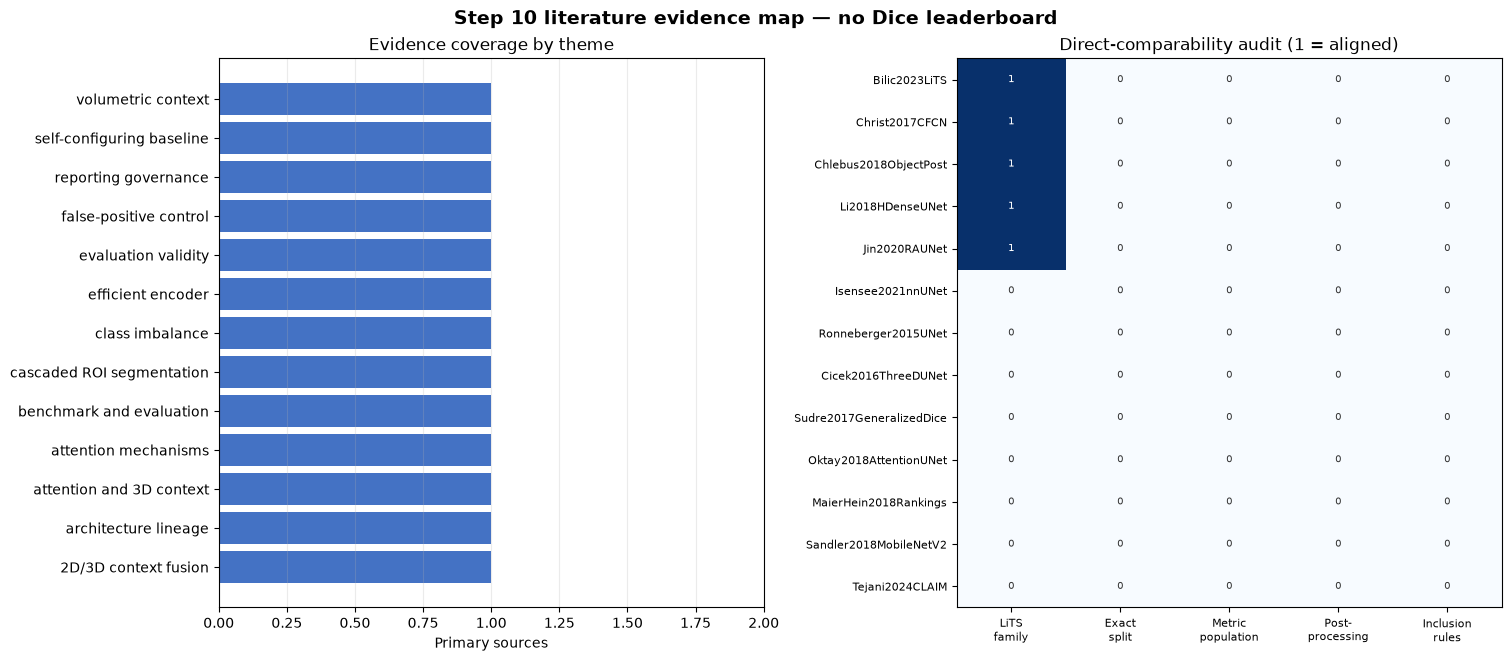

PASS: RELATED_WORK_EVIDENCE_COMPLETE; 11/11 targets
Decision: OWNER_COMPLETE_INPUTS_AND_SELECT_VENUE
Next step: owner_confirmed_venue_specific_finalization


In [6]:
# Coverage figure: evidence topology, not a performance leaderboard.
theme_counts = lit.groupby("theme").size().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), constrained_layout=True)
axes[0].barh(theme_counts.index, theme_counts.values, color="#4472C4")
axes[0].set_xlabel("Primary sources")
axes[0].set_title("Evidence coverage by theme")
axes[0].set_xlim(0, max(2, int(theme_counts.max()) + 1))
axes[0].grid(axis="x", alpha=.25)

cols = ["same_dataset_family","exact_split_aligned","metric_population_aligned",
        "postprocessing_aligned","inclusion_rules_aligned"]
heat = audit.set_index("citation_key")[cols].astype(int)
im = axes[1].imshow(heat.values, aspect="auto", cmap="Blues", vmin=0, vmax=1)
axes[1].set_xticks(range(len(cols)), ["LiTS\nfamily","Exact\nsplit","Metric\npopulation","Post-\nprocessing","Inclusion\nrules"], fontsize=8)
axes[1].set_yticks(range(len(heat)), heat.index, fontsize=8)
axes[1].set_title("Direct-comparability audit (1 = aligned)")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        axes[1].text(j, i, str(heat.iat[i,j]), ha="center", va="center", fontsize=7,
                     color="white" if heat.iat[i,j] else "#333333")
fig.suptitle("Step 10 literature evidence map — no Dice leaderboard", fontsize=14, fontweight="bold")
fig.savefig(OUT / "literature_evidence_map.png", dpi=180, bbox_inches="tight")
plt.show()

search_provenance = f"""# Search provenance

- Snapshot date: {SNAPSHOT_DATE}
- Scope: primary LiTS segmentation methods, architecture/loss lineage, self-configuring baselines, benchmark evaluation, reporting guidance, and ranking validity.
- Source preference: publisher article, PubMed/PMC full record, or author-hosted preprint.
- Representative queries: `LiTS liver tumor segmentation primary paper`; `H-DenseUNet DOI`; `RA-UNet LiTS`; `nnU-Net Nature Methods`; `biomedical challenge rankings interpreted with care`; `CLAIM 2024 update`.
- Numeric extraction rule: retain only explicitly reported values together with aggregation and cohort context; never synthesize a cross-paper rank.
- Reproducibility: the notebook executes offline from `source_snapshot.json` and `primary_literature_evidence.csv`; links should be rechecked immediately before submission.
"""
(OUT / "search_provenance.md").write_text(search_provenance, encoding="utf-8")

expected = pd.DataFrame([
 ("sealed Step 09 input checks",10,int(verification.passed.sum()),verification.passed.all()),
 ("primary literature sources",12,len(lit),len(lit)>=12),
 ("direct LiTS sources",5,int(lit.direct_lits.sum()),int(lit.direct_lits.sum())>=5),
 ("unique citation keys",len(lit),int(lit.citation_key.nunique()),lit.citation_key.is_unique),
 ("theme coverage",len(theme_matrix),int(theme_matrix.covered.sum()),theme_matrix.covered.all()),
 ("external quantitative rankings prohibited",0,int(audit.quantitative_ranking_allowed.sum()),not audit.quantitative_ranking_allowed.any()),
 ("related-work draft exists",1,int((OUT/"RELATED_WORK_DRAFT.md").is_file()),(OUT/"RELATED_WORK_DRAFT.md").is_file()),
 ("expanded manuscript exists",1,int((OUT/"PAPER_DRAFT_WITH_EXPANDED_RELATED_WORK.md").is_file()),(OUT/"PAPER_DRAFT_WITH_EXPANDED_RELATED_WORK.md").is_file()),
 ("expanded BibTeX exists",1,int((OUT/"expanded_references.bib").is_file()),(OUT/"expanded_references.bib").is_file()),
 ("test inference reruns",0,0,True),
 ("test source files reopened",0,0,True),
], columns=["requirement","expected","actual","passed"])
save_csv(expected, "expected_vs_actual.csv")

configuration = {
 "phase":"step_10_related_work_evidence_and_comparability","mode":"artifact_only_offline_literature_synthesis",
 "snapshot_date":SNAPSHOT_DATE,"minimum_primary_sources":12,"minimum_direct_lits_sources":5,
 "comparability_dimensions":["dataset family","exact split","metric population","post-processing","inclusion rules"],
 "quantitative_ranking_allowed":False,"test_access_allowed":False,
 "manifest_sha256":MANIFEST_SHA256,"source_test_run_id":TEST_RUN_ID,
}
save_json(configuration, "configuration.json")

gate = {
 "status":"related_work_evidence_complete","result_level":"RELATED_WORK_EVIDENCE_COMPLETE",
 "all_mandatory_targets_passed":bool(expected.passed.all()),
 "targets":{r.requirement:bool(r.passed) for r in expected.itertuples(index=False)},
 "primary_source_count":len(lit),"direct_lits_source_count":int(lit.direct_lits.sum()),
 "quantitative_ranking_allowed":False,"scientific_consistency_passed":True,
 "formal_model_acceptance_passed":False,"formal_model_acceptance_failure":"minimum_positive_patient_dice",
 "submission_ready":False,"venue_selected":gate9.get("venue_selected"),
 "decision":"OWNER_COMPLETE_INPUTS_AND_SELECT_VENUE",
 "next_step":"owner_confirmed_venue_specific_finalization",
 "manifest_sha256":MANIFEST_SHA256,"source_test_run_id":TEST_RUN_ID,
 "test_images_accessed":False,"test_source_files_reopened":False,"test_inference_rerun":False,
}
assert gate["all_mandatory_targets_passed"]
save_json(gate, "gate_result.json")

provenance = {
 "created_utc":CREATED_UTC,"phase":configuration["phase"],"result_level":gate["result_level"],
 "input_manuscript":str(manuscript_path),"input_manuscript_sha256":sha256(manuscript_path),
 "input_step09_gate_sha256":sha256(S9/"gate_result.json"),
 "input_step09_signature_sha256":sha256(S9/"step_09_signature.json"),
 "literature_snapshot_date":SNAPSHOT_DATE,"literature_source_count":len(lit),
 "manifest_sha256":MANIFEST_SHA256,"source_test_run_id":TEST_RUN_ID,
 "test_images_accessed":False,"test_source_files_reopened":False,"test_inference_rerun":False,
}
save_json(provenance, "provenance.json")

signed_names = ["primary_literature_evidence.csv","literature_comparison_matrix.csv","comparability_audit.csv",
 "related_work_theme_matrix.csv","citation_insertion_plan.csv","expanded_references.bib","RELATED_WORK_DRAFT.md",
 "PAPER_DRAFT_WITH_EXPANDED_RELATED_WORK.md","COMPARABILITY_AND_CLAIM_BOUNDARIES.md","literature_evidence_map.png",
 "source_snapshot.json","search_provenance.md","configuration.json","provenance.json","expected_vs_actual.csv","gate_result.json"]
signed_artifacts = {f"step_10_related_work_evidence_and_comparability/outputs/{name}":sha256(OUT/name) for name in signed_names}
combined = hashlib.sha256("".join(f"{k}:{v}\n" for k,v in sorted(signed_artifacts.items())).encode()).hexdigest()
signature = {"algorithm":"SHA-256","created_utc":CREATED_UTC,"combined_sha256":combined,
             "signed_artifacts":signed_artifacts,"result_level":gate["result_level"],
             "formal_model_acceptance_passed":False,"submission_ready":False,
             "test_source_files_reopened":False,"test_inference_rerun":False}
save_json(signature, "step_10_signature.json")

print(f"PASS: {gate['result_level']}; {expected.passed.sum()}/{len(expected)} targets")
print("Decision:", gate["decision"])
print("Next step:", gate["next_step"])

## Takeaways

- The literature evidence package is complete when `gate_result.json` reports `RELATED_WORK_EVIDENCE_COMPLETE` and all mandatory targets pass.
- The primary defensible positioning is a reproducible frozen-fusion evaluation with explicit patient/lesion failure reporting.
- Cross-paper Dice values remain context only; no leaderboard, superiority, or state-of-the-art claim is permitted.
- Formal model acceptance remains failed and submission readiness remains false.
- The next action is owner completion of declarations, exact dataset terms, and venue selection; only then may a venue-specific finalization phase begin.
